In [1]:
#Packages
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import collocations
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import time
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
#Nltk functions
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

True

In [3]:
#Loading Dataset
phrasebank_df = pd.read_csv(
    r"C:\Users\USER\PycharmProjects\ThesisProject\Data\PhraseBank\Sentences_AllAgree.txt",
    sep='@',
    names=['sentence', 'sentiment'],
    encoding='latin1',
    engine='python'
)
print(phrasebank_df.head(3))

                                            sentence sentiment
0  According to Gran , the company has no plans t...   neutral
1  For the last quarter of 2010 , Componenta 's n...  positive
2  In the third quarter of 2010 , net sales incre...  positive


In [4]:
#Viewing Distribution
print(phrasebank_df.shape)
print(phrasebank_df['sentiment'].value_counts())

(2264, 2)
sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


In [5]:
#Function to add numerical labels
def labels(x):
    if x.lower() == 'positive':
        return 2
    elif x.lower() == 'neutral':
        return 1
    else:
        return 0

In [6]:
phrasebank_df['sent_label'] = phrasebank_df['sentiment'].apply(labels)

In [7]:
print(phrasebank_df.head(3))

                                            sentence sentiment  sent_label
0  According to Gran , the company has no plans t...   neutral           1
1  For the last quarter of 2010 , Componenta 's n...  positive           2
2  In the third quarter of 2010 , net sales incre...  positive           2


In [8]:
#Sentiment Label Distribution
phrasebank_df['sent_label'].value_counts()

sent_label
1    1391
2     570
0     303
Name: count, dtype: int64

Above matches the sentiment column values

The same pre-processing stages applied to the news dataset was applied here

In [9]:
#Initiating Lemmatizer
lemmatizer = WordNetLemmatizer()

In [10]:
#Stopword and Rescue strategy
def get_final_stops():
    stop_words = set(stopwords.words('english'))
    
    #Rescue lIST : Critical for Financial Sentiment
    #Will be removed from the stopword list so they are NOT deleted.
    rescue_list = {
        'not', 'no', 'never', 'none', 'neither', 'nor', 'but', 
        'up', 'down', 'above', 'below', 'higher', 'lower', 'high', 'low',
        'off', 'under', 'over', 'against', 'only',
        'growth', 'gain', 'loss', 
    }
    
    for word in rescue_list:
        stop_words.discard(word)
    
    #Adding noise artifacts and single letters to the final ban list
    #'wa' is added to catch the common WordNet lemmatization error of 'was'
    noise_artifacts = {'would', 'could', 'also', 'wa', 'ha', 'get', 'take'}
    alphabet_noise = set(string.ascii_lowercase) - {'a', 'i'}
    
    final_stops = stop_words.union(noise_artifacts).union(alphabet_noise)
    return final_stops

FINAL_STOPS = get_final_stops()

In [11]:
#Pre-compiled Regex
#USA Pattern: Normalizes all variants into 'usa'
USA_PATTERN = re.compile(r'\b(u\.s\.a\.|u\.s\.a|usa|u\.s\.|u\.s|u\s+s)\b', re.IGNORECASE)

#Abbreviation Collapser: i.e 'i.m.f.' -> 'imf'
ABV_PROTECT_RE = re.compile(r'(?<=[a-z])\.(?=[a-z])')

#Noise Cleaner: Keeps letters and numbers
CLEAN_ALPHA_NUM_RE = re.compile(r'[^a-z0-9\s]')

#Digit Masking: Turns specific numbers into a generic 'num' feature
DIGIT_MASK_RE = re.compile(r'\b\d+(?:\.\d+)?(?:m|b|k|%)?\b')

In [12]:
#Master Pre-procesing Function
def preprocess_fin_text(text):
    
    if not isinstance(text, str) or text.strip() == "":
        return ""

    #Case Folding
    text = text.lower()
    
    #USA Normalization
    text = USA_PATTERN.sub('placeholderusa', text)

    #Collapsing identical concepts - i.e mln > million
    text = re.sub(r'\b(mn|mln)\b', 'million', text)
    text = re.sub(r'\beur\b', 'euro', text)

    #Collapsing Abbreviations
    text = ABV_PROTECT_RE.sub('', text)

    #Metric Masking (Preserves context of magnitude without feature sparsity)
    # This turns '5.2%' or '100m' into 'num'
    text = DIGIT_MASK_RE.sub('num', text)

    #Removes Punctuation/Special Characters
    text = CLEAN_ALPHA_NUM_RE.sub(' ', text)

    #Whitespace Tokenization
    tokens = text.split()

    #Lemmatization and Final Stopword Filtering
    cleaned_tokens = []
    for w in tokens:
        w_lem = lemmatizer.lemmatize(w)
        
        if w_lem not in FINAL_STOPS:
            # Restore USA placeholder
            if w_lem == 'placeholderusa':
                cleaned_tokens.append('usa')
            else:
                cleaned_tokens.append(w_lem)

    return " ".join(cleaned_tokens)

In [13]:
#Validation 
test_samples = [
    "The U.S. economy did not grow by 5% in Q1.",
    "Revenue was up by 10.5M but margins fell below expectations.",
    "Discussion by u s officials regarding U.S.A. trade in the U.K."
]

print("Pipeline Validation")
for sample in test_samples:
    print(f"Raw: {sample}")
    print(f"Proc: {preprocess_fin_text(sample)}\n")

Pipeline Validation
Raw: The U.S. economy did not grow by 5% in Q1.
Proc: usa economy not grow num q1

Raw: Revenue was up by 10.5M but margins fell below expectations.
Proc: revenue up num but margin fell below expectation

Raw: Discussion by u s officials regarding U.S.A. trade in the U.K.
Proc: discussion usa official regarding usa trade uk



In [14]:
#Running on the Phrasebank dataset
phrasebank_df['P_sentence'] = phrasebank_df['sentence'].apply(preprocess_fin_text)

In [15]:
phrasebank_df.head(3)

,sentence,sentiment,sent_label,P_sentence
0,"According to Gran , the company has no plans t...",neutral,1,according gran company no plan move production...
1,"For the last quarter of 2010 , Componenta 's n...",positive,2,last quarter num componenta net sale doubled e...
2,"In the third quarter of 2010 , net sales incre...",positive,2,third quarter num net sale increased num euro ...


In [16]:
#Validating Random Sentences in the Dataset
import random

sample_indices = random.sample(
    range(len(phrasebank_df)), 3
)

for idx in sample_indices:

    print("\nRAW TEXT:\n")
    print(phrasebank_df.loc[idx, 'sentence'][:700])

    print("\nPROCESSED TEXT:\n")
    print(phrasebank_df.loc[idx, 'P_sentence'][:700])


RAW TEXT:

In August-October 2010 , the company 's result before taxes totalled EUR 9.6 mn , up from EUR 0.5 mn in the corresponding period in 2009 .

PROCESSED TEXT:

august october num company result tax totalled euro num million up euro num million corresponding period num

RAW TEXT:

Quality chargers under CHARGZ brand are sold in selected retail stores and other sales locations world-wide .

PROCESSED TEXT:

quality charger under chargz brand sold selected retail store sale location world wide

RAW TEXT:

15 December 2010 - Finnish-German telecoms equipment maker Nokia Siemens Networks said today it won a contract to upgrade the radio network of home-based telecommunications company Elisa Oyj HEL : ELI1V .

PROCESSED TEXT:

num december num finnish german telecom equipment maker nokia siemens network said today contract upgrade radio network home based telecommunication company elisa oyj hel eli1v


In [17]:
#Checking if there are any missing values after pre-processing
print(phrasebank_df.isnull().sum())

sentence      0
sentiment     0
sent_label    0
P_sentence    0
dtype: int64


In [18]:
#Vocabulary Compression Ratio (VCR)
def calculate_vcr(df, raw_col, proc_col):
    # Get set of unique tokens for Raw
    raw_vocab = set(" ".join(df[raw_col].fillna('').astype(str)).split())
    # Get set of unique tokens for Processed
    proc_vocab = set(" ".join(df[proc_col].fillna('').astype(str)).split())
    
    vcr = 1 - (len(proc_vocab) / len(raw_vocab))
    
    print(f"--- Vocabulary Compression Analysis ---")
    print(f"Raw Unique Tokens:       {len(raw_vocab):,}")
    print(f"Processed Unique Tokens: {len(proc_vocab):,}")
    print(f"Vocabulary Reduction:    {vcr:.2%}")
    
    return vcr

calculate_vcr(phrasebank_df, 'sentence', 'P_sentence')

--- Vocabulary Compression Analysis ---
Raw Unique Tokens:       7,716
Processed Unique Tokens: 5,031
Vocabulary Reduction:    34.80%


0.3479782270606532

In [19]:
#Word frequency check to audit the cleaned data

#Combine all cleaned sentences into one massive string and split into individual words
all_words = " ".join(phrasebank_df['P_sentence'].astype(str)).split()

#Counter to calculate frequencies
word_counts = Counter(all_words)

#Extracting the 10 most common tokens
top_20_words = word_counts.most_common(10)

#Converting to a clean DataFrame for clear presentation
frequency_df = pd.DataFrame(top_20_words, columns=['Word/Token', 'Frequency'])

print("Top 10 Most Frequent Tokens")
print(frequency_df)

Top 10 Most Frequent Tokens
  Word/Token  Frequency
0        num       3732
1    million        904
2       euro        900
3    company        384
4     profit        325
5        net        292
6       sale        279
7       year        274
8      share        266
9    finnish        224


In [20]:
#Train Test Split
# Features and Targets
X = phrasebank_df['P_sentence'].astype(str)
y = phrasebank_df['sent_label']

#Stratified split for class imbalance control
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (1811,)
Testing shape: (453,)


In [21]:
#Vectorization via TF-IDF
#Initializing the vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

#Fitting the data
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [22]:
#Modelling

In [23]:
#Support Vector Machine (Linear Kernel works best for sparse text vectors)
svm = SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train_vec, y_train)

SVC(class_weight='balanced', kernel='linear', probability=True, random_state=42)

In [24]:
#Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [25]:
#Evaluation
models = {'Support Vector Machine': svm, 'Logistic Regression': lr}

print("\nBASELINE SENTIMENT EXTRACTION PERFORMANCE\n")
for name, model in models.items():
    preds = model.predict(X_test_vec)
    acc = accuracy_score(y_test, preds)
    
    print(f"{name}")
    print(f"Overall Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=['Negative', 'Neutral', 'Positive']))


BASELINE SENTIMENT EXTRACTION PERFORMANCE

Support Vector Machine
Overall Accuracy: 0.9029
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.86        61
     Neutral       0.96      0.93      0.94       278
    Positive       0.81      0.84      0.83       114

    accuracy                           0.90       453
   macro avg       0.87      0.89      0.88       453
weighted avg       0.90      0.90      0.90       453

Logistic Regression
Overall Accuracy: 0.8786
              precision    recall  f1-score   support

    Negative       0.83      0.85      0.84        61
     Neutral       0.92      0.92      0.92       278
    Positive       0.79      0.78      0.79       114

    accuracy                           0.88       453
   macro avg       0.85      0.85      0.85       453
weighted avg       0.88      0.88      0.88       453



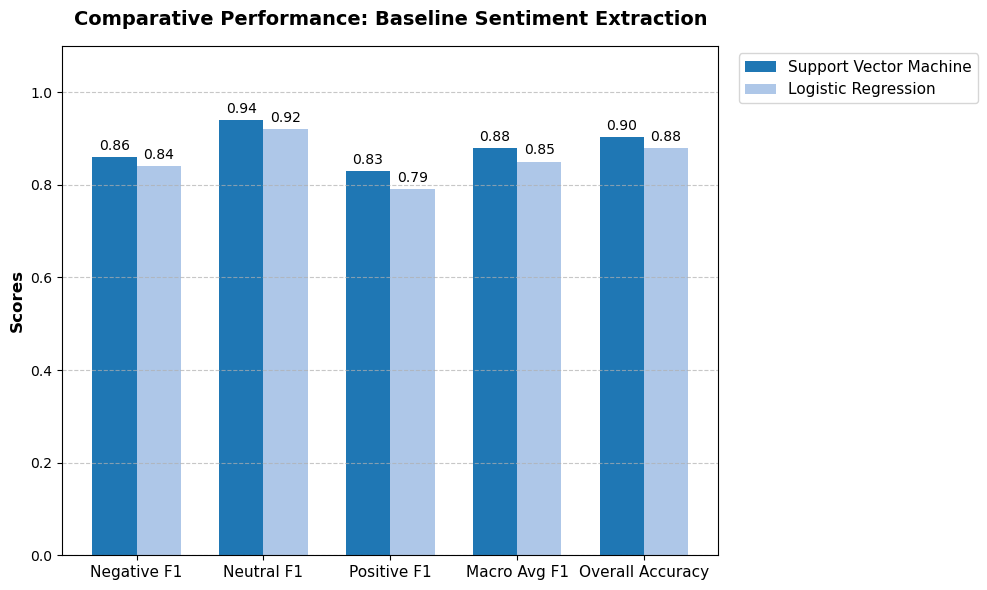

In [26]:
#Model Performance Visual
#Data setup
categories = ['Negative F1', 'Neutral F1', 'Positive F1', 'Macro Avg F1', 'Overall Accuracy']
svm_scores = [0.86, 0.94, 0.83, 0.88, 0.9029]
lr_scores = [0.84, 0.92, 0.79, 0.85, 0.8786]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, svm_scores, width, label='Support Vector Machine', color='#1f77b4')
rects2 = ax.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='#aec7e8')

#Styling
ax.set_ylabel('Scores', fontsize=12, fontweight='bold')
ax.set_title('Comparative Performance: Baseline Sentiment Extraction', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11)

#Adding value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('baseline_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
#Saving vectorizer and Models
#TF-IDF Vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

#Sentiment scorers
joblib.dump(svm, 'svm_sentiment_scorer.pkl')
joblib.dump(lr, 'logistic_regression_scorer.pkl')
print('Saved Successfully')

Saved Successfully
